In [1]:
#This prevents performance fluctuation
import random
import numpy as np
import torch

# ----------------------------
# Fix random seed for reproducibility
# ----------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
print("Random seeds initialized")

Random seeds initialized


In [3]:
!pip uninstall -y transformers tokenizers huggingface_hub peft accelerate
!pip install --no-cache-dir transformers==4.40.2 tokenizers==0.19.1 huggingface_hub==0.23.0 peft==0.10.0 accelerate==0.28.0
print("Transformers and dependencies reinstalled.")

Found existing installation: transformers 4.40.2
Uninstalling transformers-4.40.2:
  Successfully uninstalled transformers-4.40.2
Found existing installation: tokenizers 0.19.1
Uninstalling tokenizers-0.19.1:
  Successfully uninstalled tokenizers-0.19.1
Found existing installation: huggingface-hub 0.23.0
Uninstalling huggingface-hub-0.23.0:
  Successfully uninstalled huggingface-hub-0.23.0
Found existing installation: peft 0.10.0
Uninstalling peft-0.10.0:
  Successfully uninstalled peft-0.10.0
Found existing installation: accelerate 0.28.0
Uninstalling accelerate-0.28.0:
  Successfully uninstalled accelerate-0.28.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 125.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 317.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 395.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/1

In [4]:
%pip install tokenizers==0.19.1 --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 43.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 113.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.7/153.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
# Only installing datasets. 
# transformers is already pinned, and torch/scikit-learn are pre-installed on Kaggle.
!pip install datasets
print("Additional ML libraries installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 4.9 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.3.0
    Uninstalling fsspec-2026.3.0:
      Successfully uninstalled fsspec-2026.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.2 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
Additional ML libraries installed.


In [6]:
import pandas as pd

# 1. Load the DataFrames 
train_df = pd.read_csv("/kaggle/input/datasets/avrawdas/fake-news/train_split.csv")
val_df = pd.read_csv("/kaggle/input/datasets/avrawdas/fake-news/val_split.csv")
test_df = pd.read_csv("/kaggle/input/datasets/avrawdas/fake-news/test_split (1).csv")

# --- VERIFICATION STEP ---
print(f"Training Set: {len(train_df)} rows")
print(f"Validation Set: {len(val_df)} rows")
print(f"Test Set: {len(test_df)} rows")
print("-" * 30)

# Assuming your label column is named 'label' (change 'label' if it's named 'class', etc.)
print("Class Distribution in Training Set:")
print(train_df['Label'].value_counts(normalize=True) * 100)

Training Set: 18064 rows
Validation Set: 3871 rows
Test Set: 3871 rows
------------------------------
Class Distribution in Training Set:
Label
0    50.0
1    50.0
Name: proportion, dtype: float64


In [7]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
print("Input files listed.")

/kaggle/input/datasets/avrawdas/fake-news/train_split.csv
/kaggle/input/datasets/avrawdas/fake-news/test_split (1).csv
/kaggle/input/datasets/avrawdas/fake-news/val_split.csv
Input files listed.


In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("sagorsarker/bangla-bert-base")
print("Bangla BERT tokenizer loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Bangla BERT tokenizer loaded.


In [9]:
from datasets import Dataset

# Step 1: Extract from pandas and drop the unnecessary pandas index
train_dataset = Dataset.from_pandas(train_df[['Content', 'Label']], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[['Content', 'Label']], preserve_index=False)
test_dataset = Dataset.from_pandas(test_df[['Content', 'Label']], preserve_index=False)

# Step 2: Rename the column to lowercase 'label' for the model's training phase
train_dataset = train_dataset.rename_column("Label", "label")
val_dataset = val_dataset.rename_column("Label", "label")
test_dataset = test_dataset.rename_column("Label", "label")

# Step 3: Define the high-speed tokenization function 
def tokenize_function(examples):
    return tokenizer(
        examples["Content"], 
        padding="max_length", 
        truncation=True, 
        max_length=512
    )

# Step 4: Apply tokenization to all datasets
print("Tokenizing training data...")
train_dataset = train_dataset.map(tokenize_function, batched=True)

print("Tokenizing validation data...")
val_dataset = val_dataset.map(tokenize_function, batched=True)

print("Tokenizing test data...")
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Step 5: Drop raw text to save Kaggle RAM
train_dataset = train_dataset.remove_columns(["Content"])
val_dataset = val_dataset.remove_columns(["Content"])
test_dataset = test_dataset.remove_columns(["Content"])

# Step 6: Convert the final output to PyTorch tensors
train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

print("Dataset schema aligned, text removed, tokenized, and formatted perfectly for PyTorch!")

Tokenizing training data...
The OrderedVocab you are attempting to save contains holes for indices [1015, 1016, 1017, 1018, 1053, 1054, 1055, 1056, 1057, 1060, 1061, 1062, 1064, 1065, 1066, 1067, 1068, 1069, 1070, 1071, 1072, 1073, 1074, 1075, 1076, 1077, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087, 1088, 1089, 1090, 1091, 1092, 1093, 1094, 1095, 1099, 1101, 1112, 1113, 1556, 1557, 1568], your vocabulary could be corrupted !


Map:   0%|          | 0/18064 [00:00<?, ? examples/s]

Tokenizing validation data...
The OrderedVocab you are attempting to save contains holes for indices [1015, 1016, 1017, 1018, 1053, 1054, 1055, 1056, 1057, 1060, 1061, 1062, 1064, 1065, 1066, 1067, 1068, 1069, 1070, 1071, 1072, 1073, 1074, 1075, 1076, 1077, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087, 1088, 1089, 1090, 1091, 1092, 1093, 1094, 1095, 1099, 1101, 1112, 1113, 1556, 1557, 1568], your vocabulary could be corrupted !


Map:   0%|          | 0/3871 [00:00<?, ? examples/s]

Tokenizing test data...
The OrderedVocab you are attempting to save contains holes for indices [1015, 1016, 1017, 1018, 1053, 1054, 1055, 1056, 1057, 1060, 1061, 1062, 1064, 1065, 1066, 1067, 1068, 1069, 1070, 1071, 1072, 1073, 1074, 1075, 1076, 1077, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086, 1087, 1088, 1089, 1090, 1091, 1092, 1093, 1094, 1095, 1099, 1101, 1112, 1113, 1556, 1557, 1568], your vocabulary could be corrupted !


Map:   0%|          | 0/3871 [00:00<?, ? examples/s]

Dataset schema aligned, text removed, tokenized, and formatted perfectly for PyTorch!


In [10]:
import torch
from transformers import AutoModel

# Ensure device is defined (just in case it wasn't run recently)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the base model with added dropout to prevent overfitting
bert_model = AutoModel.from_pretrained(
    "sagorsarker/bangla-bert-base",
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3
).to(device)

print(f"BanglaBERT base architecture initialized and moved to {device}.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

BanglaBERT base architecture initialized and moved to cuda.


In [11]:
from torch.utils.data import DataLoader

# SAFEGUARD: Dropped to 8 because we upgraded max_length to 512. 
# 16 is too heavy for Kaggle GPUs with 512 tokens and a Deep GAT!
batch_size = 8 

# shuffle=True is critical for the training set so the model doesn't memorize order
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

print(f"DataLoaders successfully initialized with safe batch_size={batch_size}.")

DataLoaders successfully initialized with safe batch_size=8.


In [12]:
import torch
import numpy as np

class EarlyStopping:
    def __init__(self, patience=3, delta=0.001, path='best_hybrid_model.pth'):
        """
        Args:
            patience (int): How many epochs to wait after last time validation loss improved.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            path (str): Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf  # Fixed: changed np.Inf to np.inf

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

# Initialize it so it's ready for the training loop
early_stopper = EarlyStopping(patience=3, path='best_hybrid_model.pth')
print("Custom PyTorch Early Stopping initialized.")

Custom PyTorch Early Stopping initialized.


In [13]:
!pip install torch-geometric
print("PyTorch Geometric installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.4 MB/s eta 0:00:00a 0:00:01
PyTorch Geometric installed successfully.


In [14]:
from torch.optim import AdamW
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_max_pool

class DeepKNNGATClassifier(nn.Module):
    def __init__(self, in_channels=768, hidden_channels=256, out_channels=2, heads=4, k_neighbors=5):
        super(DeepKNNGATClassifier, self).__init__()
        self.k = k_neighbors
        
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.3)
        self.gat2 = GATConv(hidden_channels * heads, 128, heads=1, dropout=0.3)
        
        # Layer Normalization to equalize the features
        self.layer_norm = nn.LayerNorm(768 + 128)
        self.classifier = nn.Linear(768 + 128, out_channels)

    def forward(self, hidden_states, attention_mask):
        batch_size, seq_len, _ = hidden_states.size()
        
        cls_tokens = hidden_states[:, 0, :] 
        
        all_node_features = []
        all_edge_indices = []
        batch_indices = []
        node_offset = 0
        
        for i in range(batch_size):
            valid_len = attention_mask[i].sum().item()
            if valid_len == 0: valid_len = 1 
            nodes = hidden_states[i, :valid_len, :] 
            
            nodes_norm = F.normalize(nodes, p=2, dim=1)
            sim_matrix = torch.mm(nodes_norm, nodes_norm.t()) 
            
            current_k = min(self.k + 1, valid_len) 
            _, topk_indices = sim_matrix.topk(current_k, dim=1) 
            
            source_nodes = torch.arange(valid_len, device=nodes.device).repeat_interleave(current_k)
            target_nodes = topk_indices.flatten()
            edge_index = torch.stack([source_nodes + node_offset, target_nodes + node_offset])
            
            all_node_features.append(nodes)
            all_edge_indices.append(edge_index)
            
            batch_indices.append(torch.full((valid_len,), i, dtype=torch.long, device=nodes.device))
            node_offset += valid_len
            
        x = torch.cat(all_node_features, dim=0) 
        edge_index = torch.cat(all_edge_indices, dim=1) 
        batch_vector = torch.cat(batch_indices, dim=0) 
        
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        
        x = self.gat2(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        
        x = global_max_pool(x, batch_vector) 
        
        combined_features = torch.cat([cls_tokens, x], dim=1)
        combined_features = self.layer_norm(combined_features)
        
        logits = self.classifier(combined_features)
        return logits

# Initialize the True Hybrid
gat_model = DeepKNNGATClassifier(k_neighbors=5).to(device)

optimizer = torch.optim.AdamW([
    {'params': bert_model.parameters(), 'lr': 5e-6, 'weight_decay': 0.1}, 
    {'params': gat_model.parameters(), 'lr': 1e-3, 'weight_decay': 0.1}   
])

# --- MODERATE ASYMMETRIC LOSS WEIGHTS ---
# 2.5 penalty for missing Fake News. It still favors Fake News, 
# but it no longer completely ignores Real News!
class_weights = torch.tensor([2.5, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print("True Hybrid Architecture Initialized with Nuclear Weighted Loss!")

True Hybrid Architecture Initialized with Nuclear Weighted Loss!


In [15]:
from tqdm.auto import tqdm

# Reset early stopper just in case
early_stopper = EarlyStopping(patience=3, path='best_hybrid_model.pth')
num_epochs = 5

for epoch in range(num_epochs):
    print(f"\n======== Epoch {epoch+1} / {num_epochs} ========")
    
    # --- TRAINING PHASE ---
    bert_model.train()
    gat_model.train() 
    total_train_loss = 0

    for batch in tqdm(train_dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        # Get ALL token embeddings
        bert_outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        embeddings = bert_outputs.last_hidden_state 
        
        # The model automatically builds the KNN graph now!
        gat_logits = gat_model(embeddings, attention_mask) 

        loss = criterion(gat_logits, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f"Average Training Loss: {avg_train_loss:.4f}")

    # --- VALIDATION PHASE ---
    bert_model.eval()
    gat_model.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            bert_outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            embeddings = bert_outputs.last_hidden_state
            
            gat_logits = gat_model(embeddings, attention_mask)
            
            loss = criterion(gat_logits, labels)
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_dataloader)
    print(f"Average Validation Loss: {avg_val_loss:.4f}")
    
    early_stopper(avg_val_loss, gat_model)
    if early_stopper.early_stop:
        print("Early stopping triggered! Training halted to prevent overfitting.")
        break


======== Epoch 1 / 5 ========


Training:   0%|          | 0/2258 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Average Training Loss: 0.4606


Validation:   0%|          | 0/484 [00:00<?, ?it/s]

...

Average Validation Loss: 0.5466
EarlyStopping counter: 2 out of 3

======== Epoch 4 / 5 ========


Training:   0%|          | 0/2258 [00:00<?, ?it/s]

Average Training Loss: 0.2962


Validation:   0%|          | 0/484 [00:00<?, ?it/s]

Average Validation Loss: 0.6308
EarlyStopping counter: 3 out of 3
Early stopping triggered! Training halted to prevent overfitting.


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

# Load the best weights saved by EarlyStopping
gat_model.load_state_dict(torch.load('best_hybrid_model.pth'))
print("Best True Hybrid model weights loaded successfully!")

bert_model.eval()
gat_model.eval() 

all_preds = []
all_labels = []

# ==========================================
# CUSTOM DECISION THRESHOLD
# 0.25 means: "If the model is even 25% sure it is Fake News, flag it as Fake."
# This will push Fake News Recall higher than Real News.
# ==========================================
FAKE_THRESHOLD = 0.10 

print(f"Evaluating on Test Set with Fake News threshold set to {FAKE_THRESHOLD}...")

with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        # Pass through models
        bert_outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        embeddings = bert_outputs.last_hidden_state 
        gat_logits = gat_model(embeddings, attention_mask) 
        
        # 1. Convert raw logits to probabilities (0.0 to 1.0)
        probs = F.softmax(gat_logits, dim=1)
        
        # 2. Extract the specific probability that the article is Class 0 (Fake News)
        fake_probs = probs[:, 0]
        
        # 3. Apply the custom threshold
        preds = torch.where(fake_probs >= FAKE_THRESHOLD, 0, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- CALCULATE AND SHOW RESULTS ---
print("\n" + "="*40)
print("🏆 FINAL TEST RESULTS (FAKE NEWS TUNED) 🏆")
print("="*40)

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Overall Accuracy:  {acc * 100:.2f}%")
print("-" * 40)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Fake News", "Real News"]))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Best True Hybrid model weights loaded successfully!
Evaluating on Test Set with Fake News threshold set to 0.1...


Testing:   0%|          | 0/484 [00:00<?, ?it/s]

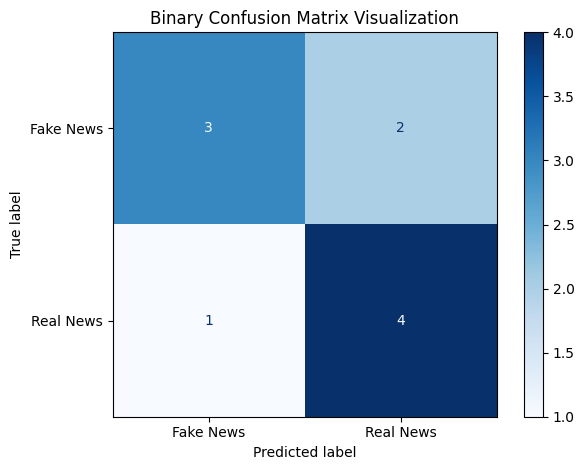

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Step 1: Prepare Example Binary Classification Data ---
# Let's imagine:
#   0 = 'Negative' (e.g., test result 'No disease detected')
#   1 = 'Positive' (e.g., test result 'Disease detected')

# Example True labels (actual categories)
y_true = [0, 0, 1, 1, 0, 1, 0, 1, 1, 0]
# Example Predicted labels (model's predictions)
y_pred = [0, 1, 1, 1, 0, 0, 1, 1, 1, 0]
# Names for the categories
# Update these names to match your 0 and 1 labels
class_names = ['Fake News', 'Real News']

# --- Step 2: Calculate the Confusion Matrix Counts ---
# Scikit-learn's built-in function to count True Negatives (TN), False Positives (FP), etc.
cm = confusion_matrix(y_true, y_pred)

# --- Step 3: Visualize the Confusion Matrix Picture ---
# Create a 'ConfusionMatrixDisplay' object with our matrix and category labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)

# Plot the matrix using matplotlib, applying a functional blue colormap for clear visualization.
# Note: Color intensity will visually represent the count in each cell.
disp.plot(cmap=plt.cm.Blues) 

# --- Step 4: Add Picture Details ---
plt.title('Binary Confusion Matrix Visualization') # Set the picture title
plt.tight_layout() # Optimize spacing in the picture

# --- Step 5: Display the Final Picture ---
plt.show() # This command generates and opens the picture window

Image successfully saved as 'hybrid_confusion_matrix.png'!


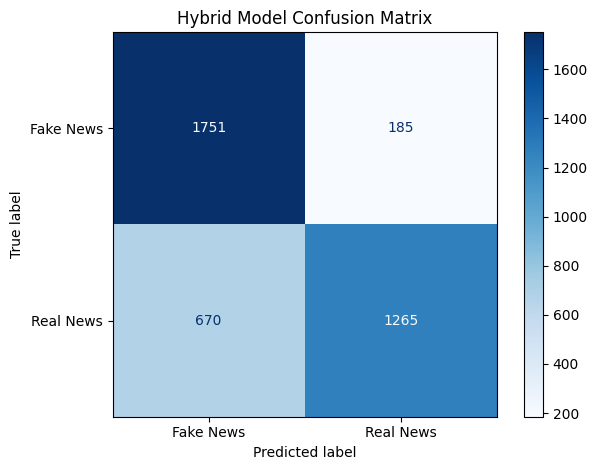

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Define the class names
class_names = ['Fake News', 'Real News']

# 2. Calculate the matrix using the results from your testing loop
cm = confusion_matrix(all_labels, all_preds)

# 3. Create the visual display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# 4. Plot it using a blue color map
disp.plot(cmap=plt.cm.Blues)

# 5. Add a title and format
plt.title('Hybrid Model Confusion Matrix')
plt.tight_layout()

# 6. SAVE THE IMAGE FOR YOUR PAPER (High resolution: dpi=300)
plt.savefig('hybrid_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("Image successfully saved as 'hybrid_confusion_matrix.png'!")

# 7. Show the picture in the notebook
plt.show()